# COE Image Generation Test
Generate counterfactual images from scenario + error chain.


In [11]:
import os
import sys
from pathlib import Path

NOTEBOOK_ROOT = Path("/scratch/jq2uw/MME/instruct_vlm_edit")
os.chdir(NOTEBOOK_ROOT)
if str(NOTEBOOK_ROOT) not in sys.path:
    sys.path.append(str(NOTEBOOK_ROOT))

from revlm.metrics.utils.e_gen_image import load_scenario_df, load_coe_sentences, build_prompt


In [12]:
# Config
MODEL_NAME = "llava-1.5-7b-hf"
DATASET = "fvqa"


## Step 1: Load Data


In [13]:
# Load scenario dataframe from HuggingFace
scenario_df = load_scenario_df(MODEL_NAME, DATASET)
print(f"Loaded {len(scenario_df)} scenarios")
scenario_df.head()


Loaded 536 scenarios


,uid,indices,scenario_1,scenario_2,scenario_3
0,230,"0,1,2",A hiker takes a sip from a reusable water bott...,A chemist carefully pours bright blue liquid f...,A child decorates a plastic bottle filled with...
1,320,"1,2","A vintage car is parked under a tree, with its...","A muddy off-road vehicle sits on a trail, with...",A sports car parked at a roadside repair shop ...
2,137,"0,1,2,3",A close-up photo reveals a tick crawling over ...,A tick is magnified under a scientist's micros...,A tick clings to the fur of a dog relaxing in ...
3,196,"0,1,2",A tranquil park shows a large lake surrounded ...,A mountain valley features a sprawling blue la...,A lakeside campground includes a vast shimmeri...
4,118,"0,1,2",A student sits in a university library surroun...,An archeologist examines an ancient artifact i...,A person gazes at archeological displays in a ...


In [14]:
# Load COE sentences
uid_to_sentences = load_coe_sentences(MODEL_NAME, DATASET)
print(f"Loaded sentences for {len(uid_to_sentences)} uids")


Loaded sentences for 811 uids


## Step 2: Preview Prompts


In [15]:
# Preview a few prompts
for _, row in scenario_df.head(3).iterrows():
    uid = str(row["uid"])
    indices = [int(i) for i in str(row["indices"]).split(",") if i]
    sentences = uid_to_sentences.get(uid, [])
    
    print(f"\n=== UID: {uid} ===")
    print(f"Indices: {indices}")
    print(f"Sentences: {sentences}")
    print(f"Error sentences: {[sentences[i] for i in indices if i < len(sentences)]}")
    
    for i in range(3):
        scenario = row.get(f"scenario_{i+1}")
        if scenario and not (isinstance(scenario, float) and str(scenario) == "nan"):
            prompt = build_prompt(scenario, sentences, indices)
            print(f"\nPrompt {i+1}: {prompt}")



=== UID: 230 ===
Indices: [0, 1, 2]
Sentences: ['The image shows a bottle.', 'Bottles are commonly designed to hold liquids.', 'People often use bottles to store or transport liquids.']
Error sentences: ['The image shows a bottle.', 'Bottles are commonly designed to hold liquids.', 'People often use bottles to store or transport liquids.']

Prompt 1: A hiker takes a sip from a reusable water bottle while resting on a rocky mountain trail. The image shows a bottle. Bottles are commonly designed to hold liquids. People often use bottles to store or transport liquids.

Prompt 2: A chemist carefully pours bright blue liquid from a glass bottle into a bubbling laboratory flask. The image shows a bottle. Bottles are commonly designed to hold liquids. People often use bottles to store or transport liquids.

Prompt 3: A child decorates a plastic bottle filled with glittery water as part of an arts-and-crafts project. The image shows a bottle. Bottles are commonly designed to hold liquids. Peo

## Step 3: Test Image Generation (Optional)


In [16]:
# # Uncomment to test image generation
# from revlm.metrics.utils.i_gen import ImageGenerator
# from data_raw.tokens import HF_TOKEN

# generator = ImageGenerator("sd3", device="cuda", token=HF_TOKEN)

# # Generate one test image (change TARGET_UID to test different samples)
# TARGET_UID = "32"  # uid is stored as string
# row = scenario_df[scenario_df["uid"] == TARGET_UID].iloc[0]
# uid = str(row["uid"])
# indices = [int(i) for i in str(row["indices"]).split(",") if i]
# sentences = uid_to_sentences.get(uid, [])
# scenario = row["scenario_1"]

# prompt = build_prompt(scenario, sentences, indices)
# print(f"Generating image for prompt:\n{prompt}")

# output_dir = Path(f"data/coe_gen_merge/image/{DATASET}/{MODEL_NAME}/{uid}")
# output_dir.mkdir(parents=True, exist_ok=True)
# save_path = output_dir / "scenario_0.png"

# if save_path.exists():
#     print(f"Image already exists: {save_path}")
#     from PIL import Image
#     image = Image.open(save_path)
# else:
#     image = generator.generate(prompt, save_path=str(save_path))
# display(image)


## Step 4: Run Full Generation (CLI)
```bash
python revlm/run/e_gen_image.py \
    --dataset_name aokvqa \
    --model_name llava-1.5-7b-hf \
    --start_idx 0 --end_idx 100 \
    --device cuda
```


In [17]:
# Check generated images
image_dir = Path(f"data/coe_gen_merge/image/{DATASET}/{MODEL_NAME}")
if image_dir.exists():
    uid_dirs = list(image_dir.iterdir())
    print(f"Generated images for {len(uid_dirs)} uids")
    
    # Count total images
    total = sum(len(list(d.glob("*.png"))) for d in uid_dirs if d.is_dir())
    print(f"Total images: {total}")
else:
    print("No images generated yet. Run the CLI command first.")


Generated images for 536 uids
Total images: 1608


## Step 5: Test get_coe_gen_input


In [19]:
from argparse import Namespace
from revlm.metrics.utils.e_gen import get_coe_gen_input
from revlm import VQADataset, configure_args

# Create config and dataset (using MODEL_NAME from Cell 2)
args = Namespace(split="all", dataset_name=DATASET)
config = configure_args(args, config_path=None)
edit_ds = VQADataset(config)

# Use all uids that have COE images as "edit" samples
image_base = Path(f"data/coe_gen_merge/image/{DATASET}/{MODEL_NAME}")
coe_uids = [d.name for d in image_base.iterdir() if d.is_dir()]
full_df = edit_ds.load_df()
edit_ds.data = edit_ds.df2data(full_df[full_df["uid"].astype(str).isin(coe_uids)])

# Load COE generality DataFrame
# Note: In full eval pipeline, config.model.name is "llava-hf/llava-1.5-7b-hf"
# and get_coe_gen_input extracts "llava-1.5-7b-hf" for image lookup
coe_df = get_coe_gen_input(DATASET, MODEL_NAME, edit_ds)
print(f"Loaded {len(coe_df)} COE generality rows")
print(f"Unique uids: {coe_df['uid'].nunique()}")
coe_df.head(6)


Task evaluation metrics will be saved to results/te/ft/llava-1.5-7b-hf/fvqa
Edit evaluation metrics will be saved to results/ee/ft/llava-1.5-7b-hf/fvqa
Predictions will be saved to results/pred/llava-1.5-7b-hf/fvqa
Post-edit predictions will be saved to results/pred_postedit/ft/llava-1.5-7b-hf/fvqa
Unified filename to save: mc_all.json
Loaded 1608 COE generality rows
Unique uids: 536


,uid,cid,question,answer,choices,idx_choices,rationale,image_path
0,4216,4216_0,Which object in this image is made of milk?,cheese,yogurt; butter; cheese; ice cream,(A) yogurt\n(B) butter\n(C) cheese\n(D) ice cream,milk is related to cheese.,data/coe_gen_merge/image/fvqa/llava-1.5-7b-hf/...
1,4216,4216_1,Which object in this image is made of milk?,cheese,yogurt; butter; cheese; ice cream,(A) yogurt\n(B) butter\n(C) cheese\n(D) ice cream,milk is related to cheese.,data/coe_gen_merge/image/fvqa/llava-1.5-7b-hf/...
2,4216,4216_2,Which object in this image is made of milk?,cheese,yogurt; butter; cheese; ice cream,(A) yogurt\n(B) butter\n(C) cheese\n(D) ice cream,milk is related to cheese.,data/coe_gen_merge/image/fvqa/llava-1.5-7b-hf/...
3,1104,1104_0,What property does the place in this image have?,covered with sand,lush vegetation; rocky terrain; covered with s...,(A) lush vegetation\n(B) rocky terrain\n(C) co...,A beach is usually covered with sand.,data/coe_gen_merge/image/fvqa/llava-1.5-7b-hf/...
4,1104,1104_1,What property does the place in this image have?,covered with sand,lush vegetation; rocky terrain; covered with s...,(A) lush vegetation\n(B) rocky terrain\n(C) co...,A beach is usually covered with sand.,data/coe_gen_merge/image/fvqa/llava-1.5-7b-hf/...
5,1104,1104_2,What property does the place in this image have?,covered with sand,lush vegetation; rocky terrain; covered with s...,(A) lush vegetation\n(B) rocky terrain\n(C) co...,A beach is usually covered with sand.,data/coe_gen_merge/image/fvqa/llava-1.5-7b-hf/...


UID: 4216, CID: 4216_0
Question: Which object in this image  is made of milk?
Answer: cheese
Image path: data/coe_gen_merge/image/fvqa/llava-1.5-7b-hf/4216/scenario_0.png


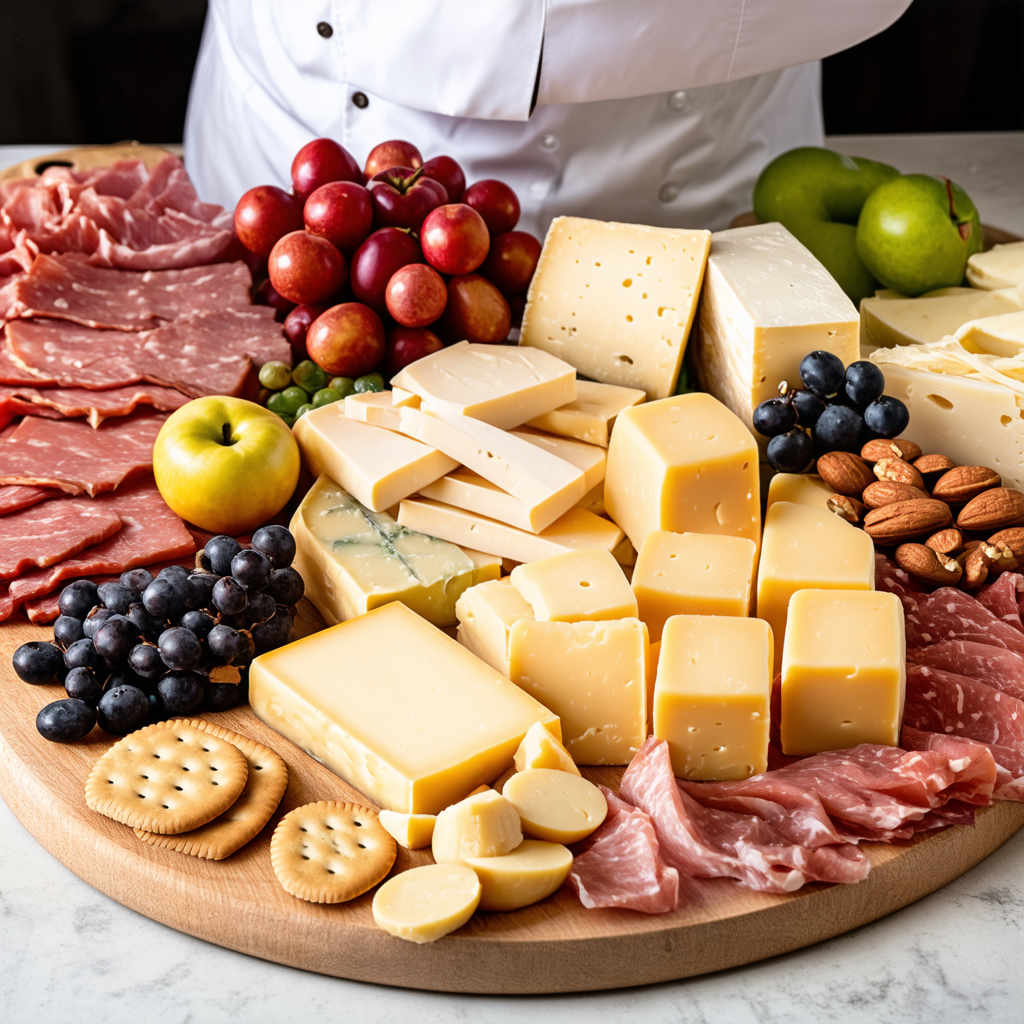

In [20]:
# Preview a sample image
if len(coe_df) > 0:
    sample = coe_df.iloc[0]
    print(f"UID: {sample['uid']}, CID: {sample['cid']}")
    print(f"Question: {sample['question']}")
    print(f"Answer: {sample['answer']}")
    print(f"Image path: {sample['image_path']}")
    
    from PIL import Image
    img = Image.open(sample['image_path'])
    display(img)
